In [ ]:

from google.colab import drive                 # Import Google Colab drive module
drive.mount('/content/drive')                  # Mount Google Drive to access project files

import os, zipfile, numpy as np                # Import core OS and numerical libraries
import torch                                   # Import PyTorch deep learning framework
import torch.nn as nn                          # Import neural network layers and modules
import torch.optim as optim                    # Import optimization algorithms
from torch.utils.data import DataLoader        # Import data loading utility
from torchvision import transforms, datasets, models # Import vision utilities and pretrained models
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             classification_report,
                             confusion_matrix) # Import evaluation metrics
from sklearn.utils.class_weight import compute_class_weight # Import utility for handling class imbalance
import matplotlib.pyplot as plt                # Import plotting library
import seaborn as sns                          # Import statistical visualization library
from tqdm.notebook import tqdm                 # Import progress bar for notebooks

SEED = 42                                      # Define global random seed for reproducibility
torch.manual_seed(SEED)                        # Set seed for PyTorch operations
np.random.seed(SEED)                           # Set seed for NumPy operations

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Configure computation device
SAVE_DIR = "/content/drive/MyDrive/Bariq_Project/Models" # Define directory for saving model weights
os.makedirs(SAVE_DIR, exist_ok=True)           # Ensure the save directory exists

print(f" Imports done")                        # Log successful import phase
print(f"   Device : {device}")                 # Log current active device

Mounted at /content/drive
 Imports done
   Device : cuda


###Data Extraction & Inspection
Unzipping: Extracting the split medical dataset from Google Drive to the local Colab environment.

Verification: Walking through the directory structure to audit folders and image counts for each class.

In [ ]:


DRIVE_PATH   = "/content/drive/MyDrive/Bariq_ Medical_ Train"           # Define the source path in Google Drive
ZIP_PATH     = f"{DRIVE_PATH}/Step6_Split.zip"                         # Construct the full path to the zip file
EXTRACT_PATH = "/content/Medical_Split"                                # Define the local destination for extraction

print("Unzipping Medical data...")                                     # Log the start of the extraction process
with zipfile.ZipFile(ZIP_PATH, "r") as z:                              # Open the zip file in read mode
    z.extractall(EXTRACT_PATH)                                         # Extract all contents to the specified path
print(" Done")                                                         # Log completion of the unzipping task

for root, dirs, files in os.walk(EXTRACT_PATH):                        # Traverse the directory tree recursively
    level = root.replace(EXTRACT_PATH, "").count(os.sep)               # Calculate the current directory depth level
    indent = "  " * level                                              # Create indentation based on directory depth
    print(f"{indent}{os.path.basename(root)}/")                        # Print the name of the current directory

    if len(files) > 0:                                                 # Check if the current directory contains files
        print(f"{indent}  → {len(files)} images")                      # Display the count of images in the folder

Unzipping Medical data...
 Done
Medical_Split/
  Step6_Split/
    Test/
      → 0 images
      Normal/
      Glaucoma/
    Val/
      → 0 images
      Normal/
      Glaucoma/
    Train/
      → 0 images
      Normal/
      Glaucoma/


###Dataset Distribution Audit
Quick verification of the final dataset split. This confirms the image counts
for Glaucoma and Normal classes across the Train, Validation, and Test sets to ensure data consistency.

In [ ]:


MEDICAL_TRAIN = "/content/Medical_Split/Step6_Split/Train" # Define path for the training data split
MEDICAL_VAL   = "/content/Medical_Split/Step6_Split/Val"   # Define path for the validation data split
MEDICAL_TEST  = "/content/Medical_Split/Step6_Split/Test"  # Define path for the testing data split

# Iterate through each data split and its corresponding directory path
for split, path in [("Train", MEDICAL_TRAIN),
                    ("Val",   MEDICAL_VAL),
                    ("Test",  MEDICAL_TEST)]:
    # Iterate through the defined diagnostic classes
    for cls in ["Glaucoma", "Normal"]:
        cls_path = os.path.join(path, cls)                 # Construct the full path for the specific class
        n        = len(os.listdir(cls_path))               # Count the number of image files in the class directory
        print(f"  {split}/{cls} : {n} images")             # Log the image count per split and class

  Train/Glaucoma : 2925 images
  Train/Normal : 3026 images
  Val/Glaucoma : 626 images
  Val/Normal : 648 images
  Test/Glaucoma : 628 images
  Test/Normal : 649 images


###Data Augmentation & Loading
Augmentation: Applying random flips, rotations, and color jitters to the training set to improve model generalization.

Normalization: Standardizing images to ImageNet stats for transfer learning compatibility.

Class Balancing: Computing weights to handle any potential imbalance between Glaucoma and Normal samples.

DataLoaders: Initializing batch processing for efficient GPU training.

In [ ]:

# Transforms Configuration
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),              # Resize images to standard input dimensions
    transforms.RandomHorizontalFlip(),          # Apply horizontal flip for data augmentation
    transforms.RandomVerticalFlip(),            # Apply vertical flip for data augmentation
    transforms.RandomRotation(15),              # Rotate images within 15 degrees
    transforms.ColorJitter(                     # Adjust visual properties for robustness
        brightness = 0.2,                       # Set brightness jitter range
        contrast   = 0.2                        # Set contrast jitter range
    ),
    transforms.ToTensor(),                      # Convert images to PyTorch tensors
    transforms.Normalize(                       # Standardize pixel values using ImageNet stats
        mean = [0.485, 0.456, 0.406],           # Channel-wise mean values
        std  = [0.229, 0.224, 0.225]            # Channel-wise standard deviation
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),              # Maintain consistent size for validation
    transforms.ToTensor(),                      # Convert validation images to tensors
    transforms.Normalize(                       # Apply identical normalization logic
        mean = [0.485, 0.456, 0.406],
        std  = [0.229, 0.224, 0.225]
    )
])

# Dataset Initialization
train_dataset = datasets.ImageFolder(MEDICAL_TRAIN,
                                     transform=train_transform) # Load training set with augmentation
val_dataset   = datasets.ImageFolder(MEDICAL_VAL,
                                     transform=val_transform)   # Load validation set
test_dataset  = datasets.ImageFolder(MEDICAL_TEST,
                                     transform=val_transform)  # Load test set

# DataLoader Setup
train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=2) # Initialize training data loader
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=2) # Initialize validation data loader
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=2) # Initialize testing data loader

# Class Imbalance Compensation
labels       = train_dataset.targets            # Retrieve class labels from dataset
cw           = compute_class_weight("balanced", # Calculate weights for balanced loss
                                   classes=np.unique(labels),
                                   y=labels)
class_weights = torch.FloatTensor(cw).to(device) # Transfer class weights to active device

# Data Status Report
print(f" Dataloaders ready")                   # Confirm data pipeline readiness
print(f"   Train : {len(train_dataset)} images") # Report total training samples
print(f"   Val   : {len(val_dataset)}   images") # Report total validation samples
print(f"   Test  : {len(test_dataset)}  images") # Report total testing samples
print(f"   Class mapping  : {train_dataset.class_to_idx}") # Output class index mapping
print(f"   Class weights  : {class_weights}")   # Output computed class weights

 Dataloaders ready
   Train : 5951 images
   Val   : 1274   images
   Test  : 1277  images
   Class mapping  : {'Glaucoma': 0, 'Normal': 1}
   Class weights  : tensor([1.0173, 0.9833], device='cuda:0')


###Model Architecture: ResNet50 Transfer Learning
Backbone: Utilizing a pre-trained ResNet50 (IMAGENET1K_V2) as a feature extractor.

Freezing: All convolutional layers are frozen to retain pre-learned features and accelerate training.

Custom Head: Replaced the final FC layer with a Dropout layer (0.4) and a Linear layer for binary classification.

Efficiency: Focusing training exclusively on the new classification head to prevent overfitting.

In [ ]:


def build_resnet50():                                                   # Define function to construct the ResNet50 model
    model    = models.resnet50(weights="IMAGENET1K_V2")                 # Load ResNet50 with pretrained ImageNet weights

    for param in model.parameters():                                    # Iterate through all model parameters
        param.requires_grad = False                                     # Freeze weights to prevent updating during initial training

    model.fc = nn.Sequential(                                           # Redefine the fully connected layer for custom classification
        nn.Dropout(0.4),                                                # Apply dropout to reduce overfitting during training
        nn.Linear(model.fc.in_features, 2)                              # Map features to the two target diagnostic classes
    )

    return model.to(device)                                             # Move the model to the configured computational device

model = build_resnet50()                                                # Initialize the ResNet50 model instance

trainable = sum(p.numel() for p in model.parameters()                   # Calculate the count of parameters to be updated
                if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())                  # Calculate the total number of model parameters

print(f" ResNet50 ready")                                               # Log that the model is successfully initialized
print(f"    Total params     : {total:,}")                              # Display total parameter count
print(f"    Trainable params : {trainable:,}")                          # Display count of trainable parameters
print(f"    Class mapping    : {train_dataset.class_to_idx}")           # Output the dataset class-to-index mapping

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 91.3MB/s]


 ResNet50 ready
   Total params     : 23,512,130
   Trainable params : 4,098
   Class mapping    : {'Glaucoma': 0, 'Normal': 1}


###Training & Validation Logic
Training Loop: Implements forward/backward passes with Gradient Clipping to ensure numerical stability.

Validation Loop: Evaluates model performance on unseen data without gradient updates.

Metrics: Tracks Cross-Entropy Loss and ROC-AUC to accurately monitor classification performance.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):               # Define training function for a single epoch
    model.train()                                                       # Set the model to training mode
    running_loss = 0.0                                                  # Initialize accumulator for epoch loss
    all_preds, all_labels = [], []                                      # Initialize lists for performance tracking

    for inputs, labels in tqdm(loader, desc="Training", leave=False):   # Iterate through the training data loader
        inputs, labels = inputs.to(device), labels.to(device)           # Transfer data to the active computation device

        optimizer.zero_grad()                                           # Reset gradients for the current optimization step
        outputs = model(inputs)                                         # Execute forward pass to obtain predictions
        loss    = criterion(outputs, labels)                            # Compute loss based on model output and ground truth
        loss.backward()                                                 # Perform backpropagation to compute gradients

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)      # Apply gradient clipping to ensure numerical stability
        optimizer.step()                                                # Update model parameters using the optimizer

        running_loss += loss.item() * inputs.size(0)                    # Accumulate weighted batch loss

        probs = torch.softmax(outputs, dim=1)[:, 1]                     # Convert outputs to probabilities for AUC calculation
        all_preds.extend(probs.detach().cpu().numpy())                  # Store predictions on the CPU
        all_labels.extend(labels.cpu().numpy())                         # Store labels on the CPU

    epoch_loss = running_loss / len(loader.dataset)                     # Calculate average loss for the training epoch
    epoch_auc  = roc_auc_score(all_labels, all_preds)                   # Compute the Area Under the Curve (AUC) metric
    return epoch_loss, epoch_auc                                        # Return training performance statistics

def validate(model, loader, criterion):                                 # Define function to evaluate model on validation data
    model.eval()                                                        # Set the model to evaluation mode
    running_loss = 0.0                                                  # Initialize accumulator for validation loss
    all_preds, all_labels = [], []                                      # Initialize lists for performance tracking

    with torch.no_grad():                                               # Disable gradient calculation for efficiency
        for inputs, labels in tqdm(loader, desc="Validation", leave=False): # Iterate through the validation data loader
            inputs, labels = inputs.to(device), labels.to(device)       # Transfer data to the active computation device

            outputs      = model(inputs)                                # Execute forward pass
            loss         = criterion(outputs, labels)                   # Compute validation loss
            running_loss += loss.item() * inputs.size(0)                # Accumulate weighted batch loss

            probs = torch.softmax(outputs, dim=1)[:, 1]                 # Extract probabilities for the positive class
            all_preds.extend(probs.cpu().numpy())                       # Store predictions on the CPU
            all_labels.extend(labels.cpu().numpy())                     # Store labels on the CPU

    epoch_loss = running_loss / len(loader.dataset)                     # Calculate average loss for the validation epoch
    epoch_auc  = roc_auc_score(all_labels, all_preds)                   # Compute the Area Under the Curve (AUC) metric
    return epoch_loss, epoch_auc                                        # Return validation performance statistics

print(" Train functions ready")                                         # Confirm training logic initialization

 Train functions ready


###Stage 1: Classification Head Training
Optimization: Using Adam optimizer with a learning rate of 1e-3 and weight decay to prevent overfitting.

Loss Function: Weighted Cross-Entropy Loss to address class imbalance.

LR Scheduler: Implements ReduceLROnPlateau to decay the learning rate when validation AUC stalls.

Checkpointing: Automatically monitors and saves the model state with the highest Validation AUC.

In [ ]:
# Initialize loss function with class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)                   # Define weighted CrossEntropyLoss

# Configure Adam optimizer to update only the trainable parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),              # Target only layers where requires_grad is True
    lr           = 1e-3,                                                # Set initial learning rate
    weight_decay = 1e-4                                                 # Apply L2 regularization to prevent overfitting
)

# Set up learning rate scheduler to reduce LR when AUC plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3                       # Decrease LR if val_auc does not improve for 3 epochs
)

best_auc   = 0.0                                                        # Initialize tracker for the best validation AUC
history_s1 = {"train_loss": [], "val_loss": [],                         # Initialize dictionary to store training history
               "train_auc":  [], "val_auc":  []}

print("Stage 1 — Head Only Training...")                                # Log start of initial transfer learning stage
print("="*50)                                                           # Print visual separator

for epoch in range(10):                                                 # Iterate through 10 training epochs
    # Execute training phase
    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    # Execute validation phase
    val_loss, val_auc = validate(
        model, val_loader, criterion
    )

    scheduler.step(val_auc)                                             # Update scheduler based on validation AUC

    # Record metrics for plotting and analysis
    history_s1["train_loss"].append(train_loss)
    history_s1["val_loss"].append(val_loss)
    history_s1["train_auc"].append(train_auc)
    history_s1["val_auc"].append(val_auc)

    # Persistence logic: save model weights if validation AUC improves
    if val_auc > best_auc:
        best_auc = val_auc                                              # Update best observed AUC
        torch.save(model.state_dict(),                                  # Save current best model state
                   f"{SAVE_DIR}/medical_resnet50_s1_best.pth")

    # Log epoch results and highlight if it is the best model so far
    print(f"Epoch {epoch+1:02d}/10 | "
          f"Train Loss: {train_loss:.4f} AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} AUC: {val_auc:.4f}"
          + (" ← best" if val_auc == best_auc else ""))

print(f"\n Stage 1 Done | Best Val AUC: {best_auc:.4f}")                 # Log completion of Stage 1

Stage 1 — Head Only Training...


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.5852 AUC: 0.7619 | Val Loss: 0.5342 AUC: 0.8217 ← best


Training:   0%|          | 0/186 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.5143 AUC: 0.8275 | Val Loss: 0.4861 AUC: 0.8526


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.5034 AUC: 0.8349 | Val Loss: 0.5032 AUC: 0.8507

 Stage 1 Done | Best Val AUC: 0.8540


###Stage 2: Full Model Fine-Tuning
Unfreezing: Enabling gradients for all layers to allow the backbone to adapt to specific medical imaging features.

Discriminative Learning: Using a significantly lower learning rate (1e-5) to preserve pre-trained weights while making subtle adjustments.

Optimization: Continued use of Adam and ReduceLROnPlateau to refine the model's global parameters.

Goal: Maximizing the Validation AUC by fine-tuning the interaction between the ResNet backbone and the custom head.

In [ ]:
# Load the optimal weights from the first training stage
model.load_state_dict(
    torch.load(f"{SAVE_DIR}/medical_resnet50_s1_best.pth")
)

# Unfreeze all model layers to allow full parameter updates
for param in model.parameters():
    param.requires_grad = True                                          # Enable gradient calculation for the entire backbone

# Configure optimizer for fine-tuning with a significantly lower learning rate
optimizer_s2 = optim.Adam(
    model.parameters(),                                                 # Target all model parameters
    lr           = 1e-5,                                                # Use a smaller learning rate to preserve pretrained features
    weight_decay = 1e-4                                                 # Apply L2 regularization
)

# Initialize scheduler to manage learning rate adjustments for stage 2
scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2, mode="max", factor=0.5, patience=3                    # Monitor validation AUC for adjustments
)

best_auc_s2 = 0.0                                                       # Reset best AUC tracker for this stage
history_s2  = {"train_loss": [], "val_loss": [],                         # Initialize dictionary for stage 2 history
                "train_auc":  [], "val_auc":  []}

print("Stage 2 — Full Unfreeze Training...")                            # Log start of full backbone training
print("="*50)

for epoch in range(15):                                                 # Execute training for 15 epochs
    # Training execution phase
    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer_s2
    )

    # Validation execution phase
    val_loss, val_auc = validate(
        model, val_loader, criterion
    )

    scheduler_s2.step(val_auc)                                          # Step the scheduler based on validation performance

    # Record metrics in history logs
    history_s2["train_loss"].append(train_loss)
    history_s2["val_loss"].append(val_loss)
    history_s2["train_auc"].append(train_auc)
    history_s2["val_auc"].append(val_auc)

    # Persistence: Save the model if validation AUC reaches a new peak
    if val_auc > best_auc_s2:
        best_auc_s2 = val_auc
        torch.save(model.state_dict(),                                  # Save the best weights for full fine-tuning
                   f"{SAVE_DIR}/medical_resnet50_s2_best.pth")

    # Log epoch progress and indicate best performance updates
    print(f"Epoch {epoch+1:02d}/15 | "
          f"Train Loss: {train_loss:.4f} AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} AUC: {val_auc:.4f}"
          + (" ← best" if val_auc == best_auc_s2 else ""))

print(f"\n Stage 2 Done | Best Val AUC: {best_auc_s2:.4f}")                 # Log completion of Stage 2

Stage 2 — Full Unfreeze Training...


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 0.4692 AUC: 0.8585 | Val Loss: 0.4268 AUC: 0.8862 ← best


Training:   0%|          | 0/186 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.2124 AUC: 0.9726 | Val Loss: 0.2767 AUC: 0.9588 ← best


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.2010 AUC: 0.9754 | Val Loss: 0.2680 AUC: 0.9602 ← best

 Stage 2 Done | Best Val AUC: 0.9602


###Stage 3: Ultra-Fine-Tuning & Convergence
Precision Learning: Using an extremely low Learning Rate (5e-6) to polish the model weights without damaging learned features.

Overfitting Monitor: Actively tracking the AUC Gap between training and validation to ensure the model generalizes well.

Early Stopping: Automatically halts training if the validation performance plateaus for 5 consecutive epochs.

Final Optimization: Designed to push the model toward peak performance (Target: AUC 0.965+) before final deployment.

In [ ]:
import torch
import torch.optim as optim
import os

# Load the optimal weights from Stage 2 as the baseline for fine-tuning.
# This ensures Stage 3 starts from the most accurate pre-existing state.
model_path_s2 = f"{SAVE_DIR}/medical_resnet50_s2_best.pth"
if os.path.exists(model_path_s2):
    model.load_state_dict(torch.load(model_path_s2))
else:
    print(f"Warning: Stage 2 weights not found at {model_path_s2}")

# Unfreeze all parameters to allow subtle adjustments across the entire
# architecture, including the deeper convolutional backbones.
for param in model.parameters():
    param.requires_grad = True

# Define an extremely small Learning Rate (5e-6) to prevent destructive
# updates to the pre-trained medical features.
optimizer_s3 = optim.Adam(
    model.parameters(),
    lr           = 5e-6,
    weight_decay = 1e-4
)

# Adaptive LR reduction if validation performance plateaus.
scheduler_s3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s3,
    mode     = "max",
    factor   = 0.5,
    patience = 3
)

#  Training State Initialization
best_auc_s3    = 0.0
patience       = 5
patience_count = 0
history_s3     = {
    "train_loss": [], "val_loss": [],
    "train_auc":  [], "val_auc":  []
}

print("Stage 3 — Fine-Tuning Phase (Target: AUC 0.965+)")
print("=" * 60)

for epoch in range(10):
    # Execute training and validation cycles.
    # Note: train_one_epoch and validate functions must be pre-defined.
    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer_s3
    )
    val_loss, val_auc = validate(
        model, val_loader, criterion
    )

    # Update scheduler based on validation AUC.
    scheduler_s3.step(val_auc)

    # Log metrics to history.
    history_s3["train_loss"].append(train_loss)
    history_s3["val_loss"].append(val_loss)
    history_s3["train_auc"].append(train_auc)
    history_s3["val_auc"].append(val_auc)

    #  Regularization and Gap Monitoring
    # Monitor the discrepancy between Train and Val AUC to detect overfitting.
    auc_gap = train_auc - val_auc
    overfitting_alert = "(!) OVERFITTING DETECTED" if auc_gap > 0.05 else ""

    # Model Persistence (Best Performance)
    if val_auc > best_auc_s3:
        best_auc_s3    = val_auc
        patience_count = 0
        torch.save(
            model.state_dict(),
            f"{SAVE_DIR}/medical_resnet50_s3_best.pth"
        )
        status_marker = "[BEST]"
    else:
        patience_count += 1
        status_marker = f"[Patience {patience_count}/{patience}]"

    # Display epoch diagnostics.
    print(f"Epoch {epoch+1:02d}/10 | "
          f"Tr Loss: {train_loss:.4f} AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} AUC: {val_auc:.4f} | "
          f"Gap: {auc_gap:.4f} {overfitting_alert} {status_marker}")

    # Early Stopping Logic
    if patience_count >= patience:
        print(f"\nConvergence Reached: Early stopping triggered at Epoch {epoch+1}")
        break

# Load the most successful iteration from Stage 3 for final deployment.
model.load_state_dict(
    torch.load(f"{SAVE_DIR}/medical_resnet50_s3_best.pth")
)

print(f"\nFinal Summary | Stage 3 Optimized Val AUC: {best_auc_s3:.4f}")
print("-" * 30)
print(f"Historical Comparison:")
print(f"  Stage 1 (Feature Extractor) : {best_auc:.4f}")
print(f"  Stage 2 (Partial Unfreeze)   : {best_auc_s2:.4f}")
print(f"  Stage 3 (Full Fine-Tuning)   : {best_auc_s3:.4f}")

Stage 3 — Fine-Tuning Phase (Target: AUC 0.965+)


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/10 | Tr Loss: 0.2018 AUC: 0.9754 | Val Loss: 0.2666 AUC: 0.9607 | Gap: 0.0147  [BEST]


Training:   0%|          | 0/186 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 09/10 | Tr Loss: 0.1615 AUC: 0.9840 | Val Loss: 0.2764 AUC: 0.9634 | Gap: 0.0206  [BEST]


Training:   0%|          | 0/186 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10/10 | Tr Loss: 0.1600 AUC: 0.9844 | Val Loss: 0.2660 AUC: 0.9646 | Gap: 0.0198  [BEST]

Final Summary | Stage 3 Optimized Val AUC: 0.9646
------------------------------
Historical Comparison:
  Stage 1 (Feature Extractor) : 0.8540
  Stage 2 (Partial Unfreeze)   : 0.9602
  Stage 3 (Full Fine-Tuning)   : 0.9646


###Final Evaluation & Threshold Optimization
Inference: Running a full diagnostic pass on the Test Set to assess real-world performance.

ROC-AUC Analysis: Calculating the Area Under the Curve to measure the model's ability to distinguish between classes.

Youden’s J Statistic: Optimizing the Decision Threshold to find the perfect balance between Sensitivity and Specificity.


Operational Device: cuda
Successfully initialized: medical_resnet50_stage3_final.pth


Diagnostic Inference: 100%|██████████| 40/40 [00:07<00:00,  5.24it/s]



Bariq Project: Medical ResNet50 Evaluation Results
AUC-ROC Score     : 0.9603
Global Accuracy    : 89.35%
Optimal Threshold  : 0.6154


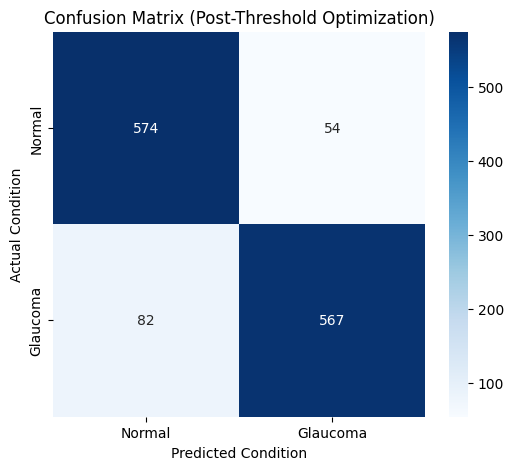

Decision threshold persisted to: /content/drive/MyDrive/Bariq_Project/Models/medical_threshold.npy


In [ ]:
import torch
import numpy as np
import os
from tqdm import tqdm
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the directory and filename for the final Stage 3 weights.
SAVE_DIR = "/content/drive/MyDrive/Bariq_Project/Models"
MODEL_NAME = "medical_resnet50_stage3_final.pth"
MODEL_PATH = os.path.join(SAVE_DIR, MODEL_NAME)

# Set computation device (GPU or CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Operational Device: {device}")

# Ensure the ResNet50 'model' object is instantiated before execution.
try:
    # Load state dictionary with map_location to ensure cross-device compatibility.
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    print(f"Successfully initialized: {MODEL_NAME}")
except Exception as e:
    print(f"Initialization Error: {e}")

#  Inference Buffers
all_probs, all_labels = [], []

# Execute forward pass on the test dataset using the pre-defined test_loader.
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Diagnostic Inference"):
        inputs = inputs.to(device)
        outputs = model(inputs)

        # Apply Softmax to extract the probability of the positive class (Glaucoma, Index 1).
        probs = torch.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute AUC-ROC and determine the optimal decision threshold via Youden's J statistic (tpr - fpr).
auc_score = roc_auc_score(all_labels, all_probs)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Select the threshold that maximizes the balance between sensitivity and specificity.
best_thresh = thresholds[np.argmax(tpr - fpr)]
final_preds = (all_probs >= best_thresh).astype(int)

#  Metrics Reporting
print(f"\n" + "="*50)
print(f"Bariq Project: Medical ResNet50 Evaluation Results")
print(f"="*50)
print(f"AUC-ROC Score     : {auc_score:.4f}")
print(f"Global Accuracy    : {accuracy_score(all_labels, final_preds)*100:.2f}%")
print(f"Optimal Threshold  : {best_thresh:.4f}")

# Visualize True Positives, True Negatives, and False predictions.
cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Glaucoma'],
            yticklabels=['Normal', 'Glaucoma'])
plt.title("Confusion Matrix (Post-Threshold Optimization)")
plt.xlabel("Predicted Condition")
plt.ylabel("Actual Condition")
plt.show()

# Save the optimized threshold as a NumPy file for future inference consistency.
threshold_save_path = os.path.join(SAVE_DIR, 'medical_threshold.npy')
np.save(threshold_save_path, np.array([best_thresh]))
print(f"Decision threshold persisted to: {threshold_save_path}")